<h1 style="text-align: center;">Bank Marketing Analysis</h1>

This project analyzes a banking dataset to identify factors that influence whether a customer subscribes to a term deposit. The analysis focuses on customer characteristics, campaign timing, and data quality to uncover patterns in subscription behavior.

Exploratory Data Analysis (EDA) is used to examine key variables, followed by a simple predictive model to validate which factors are most strongly associated with subscription outcomes.

**Key Questions:**
- What factors most influence term deposit subscriptions?
- Which customers are most likely to convert?
- How can marketing efforts be optimized?

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

## Data Cleaning

The dataset required minimal preprocessing. The target variable (deposit) was converted to a binary format, and categorical variables were encoded for modeling.

Missing values were primarily represented as "unknown". These values were counted across columns and retained to assess their impact on customer response, particularly in relation to contact information.

In [2]:
df = pd.read_csv('bank.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
unknown_counts = (df == 'unknown').sum().sort_values(ascending=False)
print("\nUnknown value counts:\n", unknown_counts[unknown_counts > 0], sep="")



Unknown value counts:
poutcome     8326
contact      2346
education     497
job            70
dtype: int64


## Exploratory Analysis
This analysis focuses on a subset of variables that are most relevant to understanding customer response, rather than examining every feature in the dataset.

#### Mean Subscription Rate
The target variable of deposit represents subscription success or failure from previous campaigns. The success rate is found and the initial results are plotted



Subscription rate: 47.38%


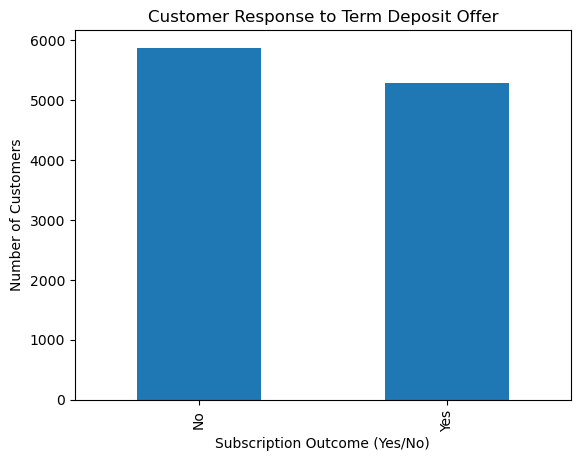

In [5]:
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0}) # target is converted to binary
        
rate = df['deposit'].mean() * 100
print(f"Subscription rate: {rate:.2f}%")

dep_counts = df['deposit'].value_counts()
dep_counts.index = ['No', 'Yes']

dep_counts.plot(kind='bar')

plt.title("Customer Response to Term Deposit Offer")
plt.xlabel("Subscription Outcome (Yes/No)")
plt.ylabel("Number of Customers")

plt.show()

**What did I find?**  
Approximately 47.4% of customers subscribed to a term deposit.

**Why might it matter?**  
This provides a baseline for evaluating which factors are associated with higher or lower subscription likelihood.

### Contact Method
Analyzing how the method of contact relates to subscription rates.

contact
cellular     54.327282
telephone    50.387597
unknown      22.591645
Name: deposit, dtype: float64


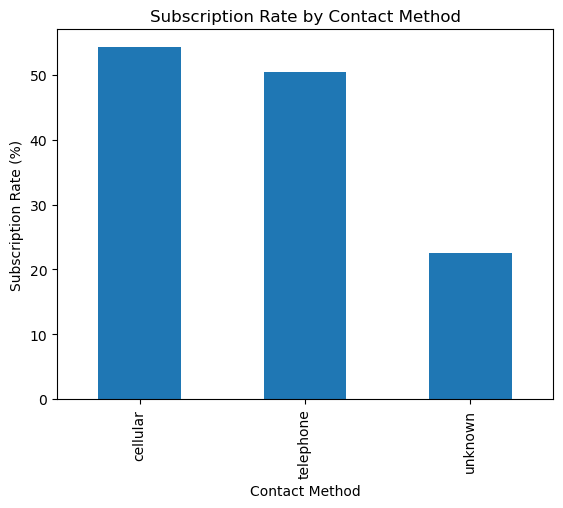

In [6]:
contact_rate = df.groupby('contact')['deposit'].mean() * 100

print(contact_rate)

contact_rate.plot(kind='bar')

plt.title("Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")

plt.show()

**What did I find?**  
Customers with known contact methods (cellular or telephone) have significantly higher subscription rates than those with unknown contact information.

**Why might it matter?**  
This suggests that data quality plays an important role in campaign effectiveness, as missing or unclear contact data is associated with lower conversion rates. These results highlight the importance of data quality in campaign effectiveness. This will be considered when evaluating other factors in the analysis.

### Previous Campaign Outcome
Analyzing how the outcome of previous marketing campaigns influences the likelihood of customer subscription.

poutcome
success    91.316527
other      57.169460
failure    50.325733
unknown    40.667788
Name: deposit, dtype: float64


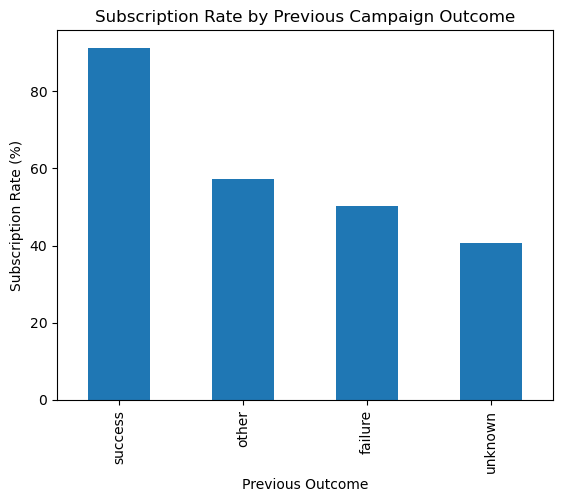

In [7]:
poutcome_rate = df.groupby('poutcome')['deposit'].mean().sort_values(ascending=False) * 100

print(poutcome_rate)

poutcome_rate.plot(kind='bar')

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Outcome")
plt.ylabel("Subscription Rate (%)")

plt.show()

**What did I find?**  
Customers with a previous successful campaign outcome have significantly higher subscription rates than all other groups.

**Why might it matter?**  
This suggests that prior engagement is one of the strongest indicators of future subscription behavior, making it a critical factor for targeting customers in future campaigns.


### Month (Campaign Timing)
Analyzing how the timing of contact throughout the year affects subscription rates.

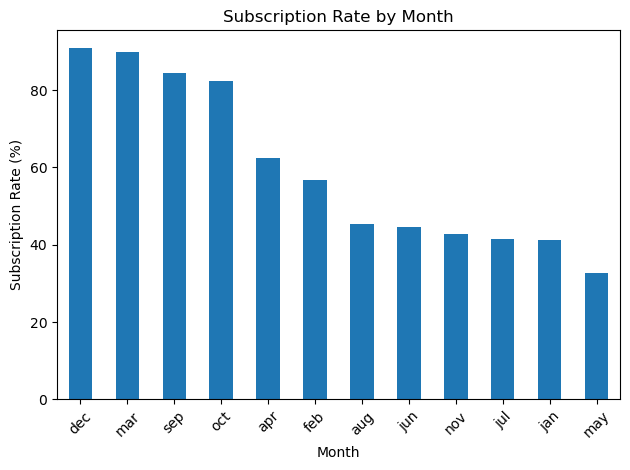

In [8]:
month_rate = df.groupby('month')['deposit'].mean().sort_values(ascending=False) * 100

month_rate.plot(kind='bar')

plt.title("Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**What did I find?**  
Subscription rates vary significantly by month, with certain months such as March, September, October, and December showing noticeably higher response rates.

**Why might it matter?**  
This indicates that campaign timing plays a major role in customer response and is possibly one of the most important factors influencing subscription behavior.

### Job Category
Analyzing how customer occupation relates to subscription rates.

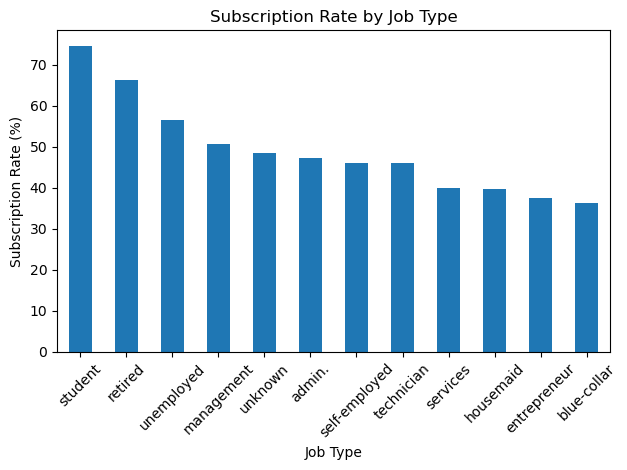

In [9]:
job_rate = df.groupby('job')['deposit'].mean().sort_values(ascending=False) * 100

job_rate.plot(kind='bar')

plt.title("Subscription Rate by Job Type")
plt.xlabel("Job Type")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**What did I find?**  
Certain job categories, such as retired and student, show higher subscription rates compared to others.

**Why might it matter?**  
This suggests that customer demographics may influence subscription behavior, though these effects appear less pronounced than factors such as campaign timing and previous outcomes.

## Predictive Modeling

A logistic regression model is used to predict whether a customer subscribes to a term deposit. The model estimates how customer and campaign features influence the likelihood of subscription.

Categorical variables are encoded and numerical features are scaled prior to modeling to ensure compatibility and consistent feature magnitudes. Model performance is evaluated using classification accuracy on a held-out test set. The results are compared with and without call duration, as this variable is only known after customer interaction. A fixed random seed is set for reproducibility.

In [10]:
X = df.drop('deposit', axis=1)
X = pd.get_dummies(X, drop_first=True)
y = df['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)
y_pred_full = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_full))
print(classification_report(y_test, y_pred_full))

Accuracy: 0.8083296014330497
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1166
           1       0.81      0.78      0.80      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



In [13]:
coef = pd.Series(model.coef_[0], index=X.columns)
coef = coef.sort_values(ascending=False)
print(coef.head(10))

duration               1.916184
poutcome_success       0.648274
month_mar              0.295705
education_tertiary     0.240892
month_oct              0.207223
month_sep              0.188732
month_dec              0.157809
education_secondary    0.120083
month_jun              0.116905
balance                0.069943
dtype: float64


In [14]:
X = df.drop(['deposit', 'duration'], axis=1)
X = pd.get_dummies(X, drop_first=True)

y = df['deposit']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy (no duration):", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy (no duration): 0.7133900582176445
              precision    recall  f1-score   support

           0       0.68      0.84      0.75      1166
           1       0.77      0.57      0.66      1067

    accuracy                           0.71      2233
   macro avg       0.73      0.71      0.71      2233
weighted avg       0.72      0.71      0.71      2233



In [18]:
coef = pd.Series(model.coef_[0], index=X.columns)
coef = coef.sort_values(ascending=False)
print(coef.head(10))

poutcome_success       0.618177
month_mar              0.205126
education_tertiary     0.177327
month_sep              0.159726
month_oct              0.151914
month_dec              0.149035
job_retired            0.095794
balance                0.079678
education_secondary    0.070408
job_student            0.055435
dtype: float64


In [19]:
summary = pd.DataFrame({
    "With Duration": [accuracy_score(y_test, y_pred_full)],
    "Without Duration": [accuracy_score(y_test, y_pred)]
}, index=["Accuracy"])

print(summary)

          With Duration  Without Duration
Accuracy        0.80833           0.71339


### Findings

The model including call duration achieved higher accuracy (80.8%), while removing it reduced accuracy (71.3%). This indicates that call duration is highly predictive, though it is not available prior to contact.

After removing duration, the model highlights more actionable predictors. Previous campaign outcome is the strongest indicator of subscription, followed by campaign timing (notably March, September, October, and December) and customer characteristics such as tertiary education and retirement status.

The variation in subscription rates across months suggests that timing may influence customer responsiveness, potentially reflecting seasonal patterns, campaign strategies, or differences in customer behavior throughout the year.

These results reinforce earlier EDA findings, particularly the importance of customer history and campaign timing in influencing subscription behavior. While contact method showed a strong relationship with subscription rates in the EDA, this effect is less pronounced in the model, suggesting it may overlap with other factors.

## Conclusion

This analysis identified key factors influencing whether customers subscribe to a term deposit. The most important drivers include previous campaign success and campaign timing, with customer characteristics playing a secondary role.

While call duration was the strongest predictor in the model, it reflects behavior during the call and is not useful for pre-contact decision-making. Removing it provided a more realistic view of actionable factors.

Data quality, particularly missing contact information, is associated with lower subscription rates, though its effect appears less pronounced when accounting for other variables in the model.

Overall, prioritizing customers with prior success and optimizing campaign timing are likely to provide the greatest improvements in future marketing outcomes.